# Correlation Analysis Per Video: MoLab Features vs IRAF SAT (n=10)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os

MOLAB_DIR   = Path('../data/processed/molab_cropped')
OUT_DIR     = '../data/processed/features/molab/per_video/'
os.makedirs(OUT_DIR, exist_ok=True)

KORS_PATH   = '../data/original/Forts_IRAF_SAT_Kors.xlsx'
RAK_PATH    = '../data/original/Forts_IRAF_SAT_RAK.xlsx'

TIME_DICT = {
    '0028': (9.90, 9.92, 9.92, 11.12, 11.19, 11.77),
    '0030': (5.80, 6.25, 6.32,  6.70,  6.76,  7.63),
    '0045': (6.54, 6.70, 6.70,  7.29,  7.45,  7.98),
    '0047': (7.03, 7.41, 7.49,  7.79,  7.97,  8.91),
    '0059': (6.65, 6.88, 6.90,  7.96,  8.19,  9.11),
    '0061': (6.00, 7.00, 7.00,  8.30,  8.40,  9.00),
    '0074': (6.07, 6.33, 6.35,  6.71,  6.90,  7.27),
    '0076': (5.00, 6.00, 6.00,  6.71,  6.90,  8.00),
    '0091': (6.39, 6.55, 6.60,  7.03,  7.18,  7.61),
    '0093': (5.86, 5.92, 6.20,  6.65,  6.92,  7.67),
}


In [2]:
def parse_iraf_per_video(xl, sheet_name):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].astype(str)
    film_rows = raw.index[col0.str.contains('Film Nr', na=False)].tolist()
    film_rows.append(len(raw))
    records = []
    for i, start in enumerate(film_rows[:-1]):
        video = col0.iloc[start].split(': ')[1].strip().zfill(4)
        block = raw.iloc[start:film_rows[i+1]]
        bc0 = block.iloc[:, 0].astype(str)
        up_idx = bc0[bc0.str.strip() == 'Utgångsposition'].index
        rs_idx = bc0[bc0.str.strip() == 'Rörelsestart'].index
        ru_idx = bc0[bc0.str.strip() == 'Rörelseutförande'].index
        if not (len(up_idx) and len(rs_idx) and len(ru_idx)):
            continue
        up_i, rs_i, ru_i = up_idx[0], rs_idx[0], ru_idx[0]
        end_i = film_rows[i+1]
        for phase, p_start, p_end in [
            ('utgångsposition', up_i+1, rs_i),
            ('rörelsestart',    rs_i+1, ru_i),
            ('rörelseutförande', ru_i+1, end_i)
        ]:
            for _, r in raw.iloc[p_start:p_end].iterrows():
                if pd.notna(r[1]) and pd.notna(r[3]) and r[5] != 'x':
                    records.append({'video': video, 'phase': phase,
                                    'weight': r[1], 'avvikelse': r[3]})
    return pd.DataFrame(records)

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
iraf_raw = pd.concat([
    parse_iraf_per_video(kors_xl, 'Sittande till stående'),
    parse_iraf_per_video(rak_xl,  'Sittande till stående'),
], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])
iraf_pv = iraf_raw.groupby(['video', 'phase'])['w'].sum().unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]
iraf_pv['iraf_total'] = iraf_pv[[c for c in iraf_pv.columns if c.startswith('iraf_')]].sum(axis=1)
print(iraf_pv)


  video  iraf_rörelsestart  iraf_rörelseutförande  iraf_utgångsposition  \
0  0028                  6                     11                    22   
1  0030                  0                      0                     1   
2  0045                  6                     15                    24   
3  0047                  0                      5                    13   
4  0059                  6                     15                    26   
5  0061                  0                      2                     5   
6  0074                  6                     15                    27   
7  0076                  0                      9                     2   
8  0091                  3                     11                    33   
9  0093                  3                      5                     8   

   iraf_total  
0          39  
1           1  
2          45  
3          18  
4          47  
5           7  
6          48  
7          11  
8          47  
9          16 

In [3]:
def get_phase(df, t_start, t_end):
    return df[(df['video_time'] >= t_start) & (df['video_time'] <= t_end)]

def rms(x): return np.sqrt(np.mean(x**2))

def extract_utgångsposition(df, t0, t1):
    p = get_phase(df, t0, t1)
    lk, rk = p['JointAngle/L_knee_X'], p['JointAngle/R_knee_X']
    return {
        'mean_L_knee_flexion':  lk.mean(),
        'mean_R_knee_flexion':  rk.mean(),
        'delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
    }

def extract_rörelsestart(df, t1, t5):
    p = get_phase(df, t1, t5)
    pelvis_x, gyro_y = p['JointAngle/pelvis_X'], p['SegmentGyro/pelvis_Y']
    return {
        'initial_pelvis_tilt': pelvis_x.iloc[0] if len(pelvis_x) else np.nan,
        'max_pelvis_tilt':     pelvis_x.max(),
        'delta_pelvis_tilt':   pelvis_x.max() - pelvis_x.min(),
        'peak_pelvis_gyro':    gyro_y.abs().max(),
        'mean_pelvis_gyro':    gyro_y.abs().mean(),
        'hip_flexion_range':   ((p['JointAngle/L_hip_X'].max() - p['JointAngle/L_hip_X'].min()) +
                                (p['JointAngle/R_hip_X'].max() - p['JointAngle/R_hip_X'].min())) / 2,
        'rms_pelvis_acc':      rms(p['SegmentAcc/pelvis_Y'].values),
    }

def extract_rörelseutförande(df, t2, t3, t4, t5):
    forb, uppr = get_phase(df, t2, t3), get_phase(df, t4, t5)
    lk_up, rk_up = uppr['JointAngle/L_knee_X'], uppr['JointAngle/R_knee_X']
    return {
        'forb_delta_pelvis_tilt':    forb['JointAngle/pelvis_X'].max() - forb['JointAngle/pelvis_X'].min(),
        'forb_peak_pelvis_gyro':     forb['SegmentGyro/pelvis_Y'].abs().max(),
        'forb_rms_pelvis_acc':       rms(forb['SegmentAcc/pelvis_Y'].values),
        'uppr_total_knee_extension': ((lk_up.max() - lk_up.min()) + (rk_up.max() - rk_up.min())) / 2,
        'uppr_peak_shank_gyro':      max(uppr['SegmentGyro/L_shank_Y'].abs().max(),
                                         uppr['SegmentGyro/R_shank_Y'].abs().max()),
        'uppr_total_hip_extension':  ((uppr['JointAngle/L_hip_X'].max() - uppr['JointAngle/L_hip_X'].min()) +
                                      (uppr['JointAngle/R_hip_X'].max() - uppr['JointAngle/R_hip_X'].min())) / 2,
    }


In [4]:
rows_up, rows_rs, rows_ru = [], [], []

for vid, times in TIME_DICT.items():
    t0, t1, t2, t3, t4, t5 = times
    df = pd.read_csv(MOLAB_DIR / f'{vid}_molab.csv')
    rows_up.append({'video': vid, **extract_utgångsposition(df, t0, t1)})
    rows_rs.append({'video': vid, **extract_rörelsestart(df, t1, t5)})
    if t3 is not None and t4 is not None:
        rows_ru.append({'video': vid, **extract_rörelseutförande(df, t2, t3, t4, t5)})

feat_up = pd.DataFrame(rows_up)
feat_rs = pd.DataFrame(rows_rs)
feat_ru = pd.DataFrame(rows_ru)

merged_up = feat_up.merge(iraf_pv[['video', 'iraf_utgångsposition']].rename(columns={'iraf_utgångsposition': 'iraf_score'}), on='video')
merged_rs = feat_rs.merge(iraf_pv[['video', 'iraf_rörelsestart']].rename(columns={'iraf_rörelsestart': 'iraf_score'}), on='video')
merged_ru = feat_ru.merge(iraf_pv[['video', 'iraf_rörelseutförande']].rename(columns={'iraf_rörelseutförande': 'iraf_score'}), on='video')
print(f'n per phase   up:{len(merged_up)}, rs:{len(merged_rs)}, ru:{len(merged_ru)}')


n per phase   up:10, rs:10, ru:10


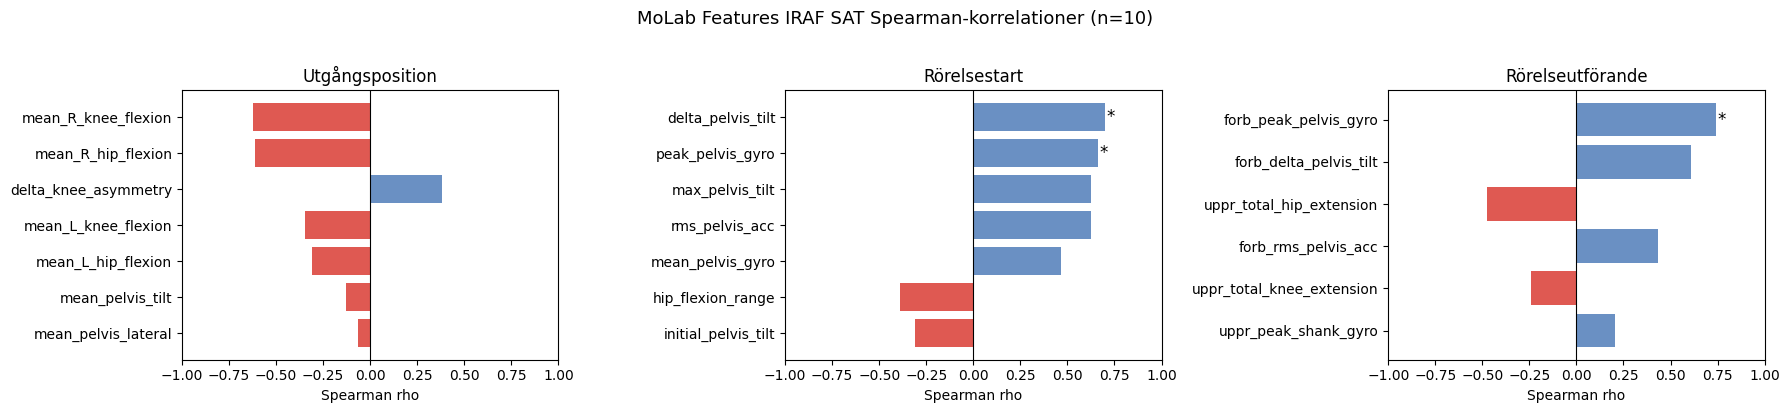

In [5]:
def spearman(df):
    return pd.DataFrame([
        {'feature': c, 'rho': stats.spearmanr(df[c], df['iraf_score'])[0],
                       'p':   stats.spearmanr(df[c], df['iraf_score'])[1]}
        for c in df.columns if c not in ['video', 'iraf_score']
        if df[[c, 'iraf_score']].dropna().__len__() >= 3
    ]).sort_values('rho', key=abs, ascending=False)

corr_up = spearman(merged_up)
corr_rs = spearman(merged_rs)
corr_ru = spearman(merged_ru)

corr_up.to_csv(OUT_DIR + 'corr_utgångsposition.csv', index=False)
corr_rs.to_csv(OUT_DIR + 'corr_rörelsestart.csv', index=False)
corr_ru.to_csv(OUT_DIR + 'corr_rörelseutförande.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, corr, title in zip(axes, [corr_up, corr_rs, corr_ru], ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('MoLab Features IRAF SAT Spearman-korrelationer (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + 'molab_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


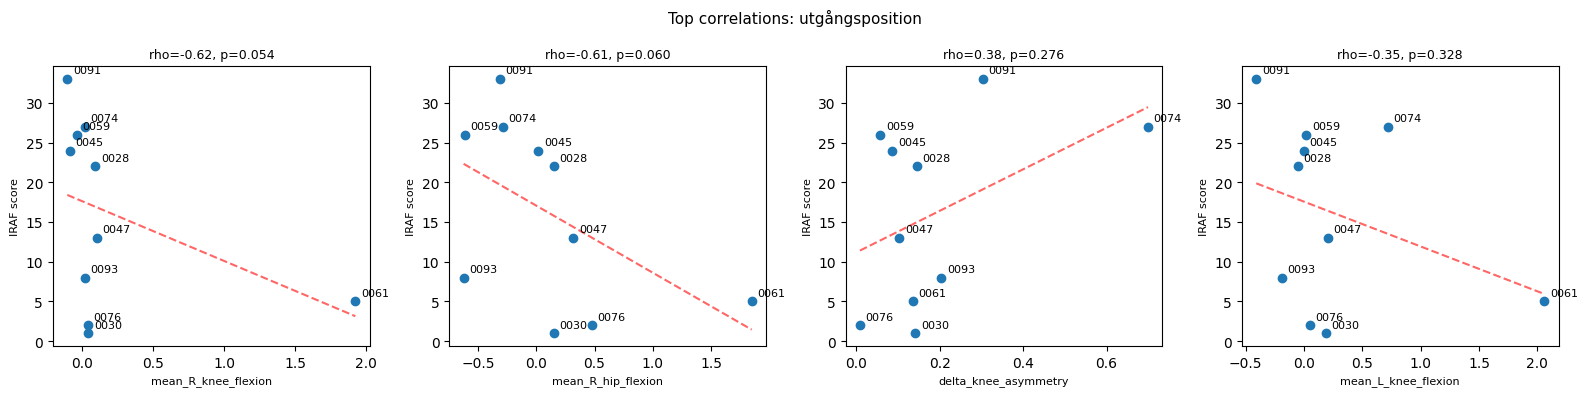

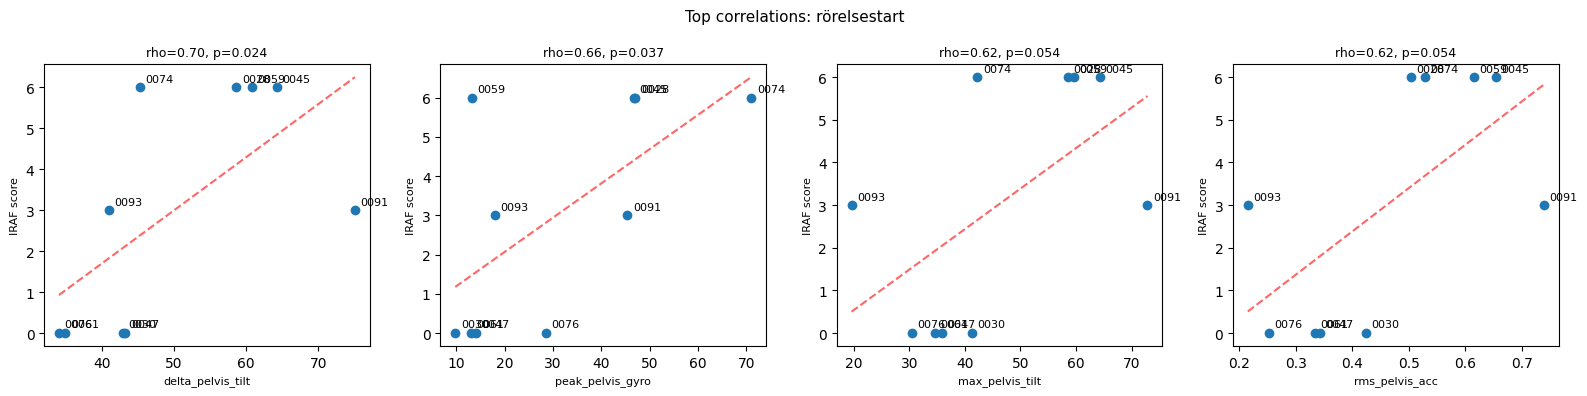

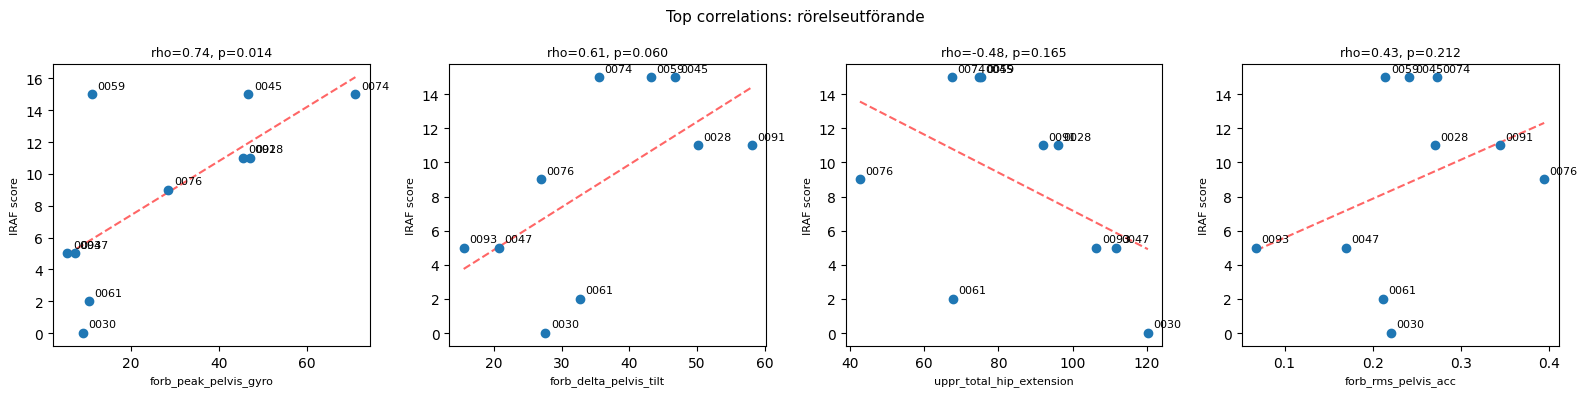

In [6]:
def plot_top_scatters(merged_df, corr_df, phase_name, n_top=4):
    top = corr_df.head(n_top)
    fig, axes = plt.subplots(1, len(top), figsize=(4*len(top), 4))
    if len(top) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, top.iterrows()):
        fc = row['feature']
        vals = merged_df[['video', fc, 'iraf_score']].dropna()
        ax.scatter(vals[fc], vals['iraf_score'], zorder=3)
        for _, r in vals.iterrows():
            ax.annotate(r['video'], (r[fc], r['iraf_score']),
                        textcoords='offset points', xytext=(4, 4), fontsize=8)
        m, b = np.polyfit(vals[fc], vals['iraf_score'], 1)
        xr = np.linspace(vals[fc].min(), vals[fc].max(), 50)
        ax.plot(xr, m*xr+b, 'r--', alpha=0.6)
        ax.set_xlabel(fc, fontsize=8)
        ax.set_ylabel('IRAF score', fontsize=8)
        ax.set_title(f'rho={row["rho"]:.2f}, p={row["p"]:.3f}', fontsize=9)
    fig.suptitle(f'Top correlations: {phase_name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}molab_scatter_{phase_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_top_scatters(merged_up, corr_up, 'utgångsposition')
plot_top_scatters(merged_rs, corr_rs, 'rörelsestart')
plot_top_scatters(merged_ru, corr_ru, 'rörelseutförande')


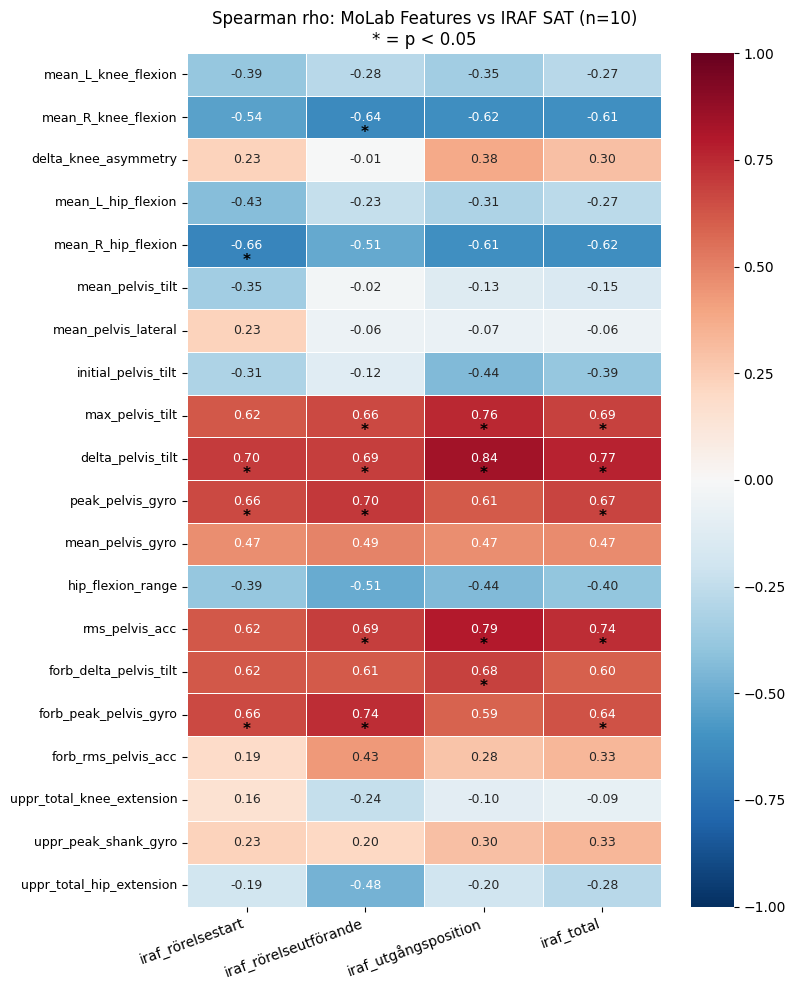

In [7]:
all_feats = feat_up.merge(feat_rs, on='video', how='outer').merge(feat_ru, on='video', how='outer')
merged_all = all_feats.merge(iraf_pv, on='video')

feat_cols = [c for c in all_feats.columns if c != 'video']
iraf_cols = [c for c in iraf_pv.columns if c != 'video']

rho_mat = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
p_mat   = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
for fc in feat_cols:
    for ic in iraf_cols:
        vals = merged_all[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat.loc[fc, ic], p_mat.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols) * 0.5)))
sns.heatmap(rho_mat.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat.isna(), annot_kws={'size': 9})
for i, fc in enumerate(feat_cols):
    for j, ic in enumerate(iraf_cols):
        if pd.notna(p_mat.loc[fc, ic]) and p_mat.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: MoLab Features vs IRAF SAT (n=10)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'molab_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
corr_results = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat.loc[fc, ic], 'p_value': p_mat.loc[fc, ic]}
    for fc in feat_cols for ic in iraf_cols
    if pd.notna(rho_mat.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results.to_csv(OUT_DIR + 'molab_correlation_results.csv', index=False)
print(f'{len(corr_results)} correlations saved')
corr_results.head(10)


80 correlations saved


,feature,iraf_score,spearman_rho,p_value
38,delta_pelvis_tilt,iraf_utgångsposition,0.842424,0.002220
54,rms_pelvis_acc,iraf_utgångsposition,0.793939,0.006100
39,delta_pelvis_tilt,iraf_total,0.772040,0.008880
34,max_pelvis_tilt,iraf_utgångsposition,0.757576,0.011143
61,forb_peak_pelvis_gyro,iraf_rörelseutförande,0.740868,0.014231
55,rms_pelvis_acc,iraf_total,0.735566,0.015323
41,peak_pelvis_gyro,iraf_rörelseutförande,0.703824,0.023114
36,delta_pelvis_tilt,iraf_rörelsestart,0.700649,0.024019
37,delta_pelvis_tilt,iraf_rörelseutförande,0.691477,0.026767
53,rms_pelvis_acc,iraf_rörelseutförande,0.691477,0.026767
